# Chest X‑Ray Pneumonia Detection

## Problem Overview  
Pneumonia is a life‑threatening infectious disease, especially in children. Chest X‑ray is the primary diagnostic tool, but interpretation can be delayed or subjective.  

This project builds an automated binary classifier to distinguish **NORMAL** from **PNEUMONIA** chest X‑ray images.

## Dataset Choice  
The [Chest X‑Ray Pneumonia dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data) is used because:
- It reflects a **real‑world medical imaging task**.
- It is **significantly imbalanced** (more pneumonia cases) – a common challenge in healthcare ML.
- It is non‑trivial (≈5,800 images), avoiding toy datasets like MNIST/CIFAR‑10.

Handling imbalance properly is essential here, and the techniques we apply (weighted sampling, class‑weighted loss) are directly motivated by this dataset characteristic.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)

import kagglehub

## 1. Data Loading & Exploration

### Overview
- The Chest X‑Ray Pneumonia dataset is downloaded using `kagglehub`.
- All image paths and corresponding labels (0 = NORMAL, 1 = PNEUMONIA) are loaded.
- The training data is split into **training (85%)** and **validation (15%)** sets using a stratified split to preserve class distribution.
- Class distribution and sample images are visualised to understand data characteristics.

In [2]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
base_path = os.path.join(path, "chest_xray")

print("Dataset loaded at:", base_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset loaded at: /kaggle/input/chest-xray-pneumonia/chest_xray


In [3]:
def load_data(data_dir):
    paths, labels = [], []

    for label_name in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(data_dir, label_name)
        label = 0 if label_name == "NORMAL" else 1

        for img in os.listdir(folder):
            if img.startswith("."):
                continue
            paths.append(os.path.join(folder, img))
            labels.append(label)

    return np.array(paths), np.array(labels)


train_paths, train_labels = load_data(os.path.join(base_path, "train"))
test_paths, test_labels = load_data(os.path.join(base_path, "test"))

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=42
)

Class distribution:
NORMAL: 1140
PNEUMONIA: 3293


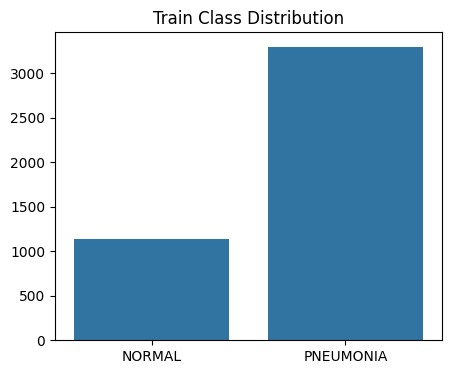

In [4]:
unique, counts = np.unique(train_labels, return_counts=True)

print("Class distribution:")
print("NORMAL:", counts[0])
print("PNEUMONIA:", counts[1])

plt.figure(figsize=(5,4))
sns.barplot(x=["NORMAL","PNEUMONIA"], y=counts)
plt.title("Train Class Distribution")
plt.show()

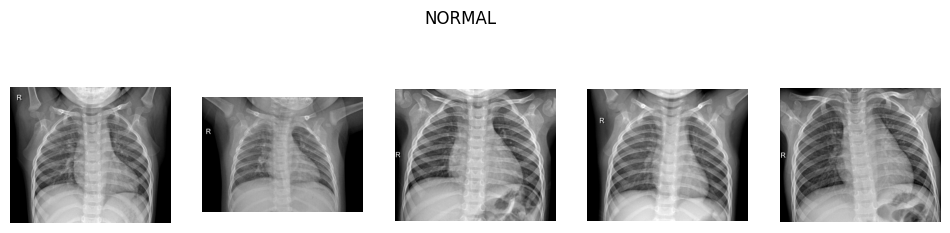

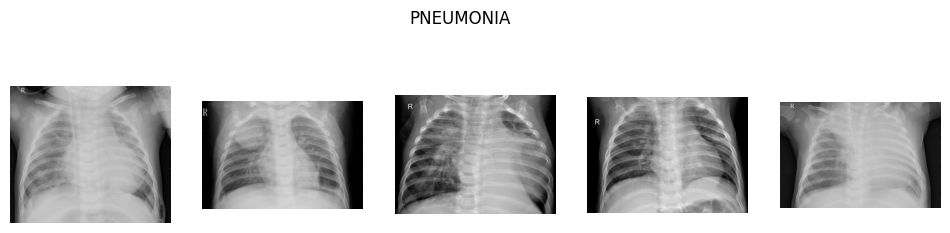

In [5]:
def show_samples(paths, labels, cls):
    plt.figure(figsize=(12,3))

    idxs = np.where(labels == cls)[0][:5]

    for i, idx in enumerate(idxs):
        img = Image.open(paths[idx]).convert("RGB")
        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    title = "NORMAL" if cls == 0 else "PNEUMONIA"
    plt.suptitle(title)
    plt.show()


show_samples(train_paths, train_labels, 0)
show_samples(train_paths, train_labels, 1)

### Results
- The dataset contains **5,856 images** (training: 4,174, test: 624). A validation set of 736 images was extracted from the training data.
- Class imbalance is confirmed: **PNEUMONIA ≈ 3× NORMAL** in the training set.
- Sample images show typical chest X‑ray appearance; both classes present visually distinguishable patterns.

**Significance**  
The observed imbalance motivated the use of **weighted sampling** and **class‑weighted loss**,  essential for a clinically useful model.

## 2. Preprocessing & Augmentation

### Overview
- All images are resized to **224×224** pixels (standard input size for pre‑trained networks).
- **ImageNet normalisation** (mean, standard deviation) is applied to align input distribution with pre‑trained weights.
- For the training set only, data augmentation includes **random rotation, horizontal flip, and colour jitter** to improve generalisation.
- A custom `ChestDataset` class handles image loading and transform application.

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
class ChestDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx]).long()

### Results
- All images are now 224×224, normalised, and ready for model input.
- Training augmentations increase effective dataset size and help the model become invariant to minor variations (patient positioning, equipment differences).

**Why this is effective**  
Augmentation reduces overfitting, critical when working with medical images where data quantity is often limited.

## 3. Handling Class Imbalance

### Overview
- Sample weights are computed inversely proportional to class frequencies.
- A `WeightedRandomSampler` is created for the training DataLoader, this oversamples the minority class.
- Class weights are computed for the loss function to penalise misclassification of the minority class more heavily.

In [11]:
class_counts = np.bincount(train_labels)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), True)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class weights:")
print(f"NORMAL (0): {class_weights[0]:.6f}")
print(f"PNEUMONIA (1): {class_weights[1]:.6f}")

Class weights:
NORMAL (0): 0.000877
PNEUMONIA (1): 0.000304


In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(
    ChestDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    ChestDataset(val_paths, val_labels, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    ChestDataset(test_paths, test_labels, val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

### Results

Class weights are 0.000877 for the NORMAL class and 0.000304 for the PNEUMONIA class. The WeightedRandomSampler ensures that each training batch has balanced class representation. The loss function, CrossEntropyLoss, uses these class weights. Weighted sampling balances the batch distribution, while weighted loss further emphasises correct classification of the rare class. Together these techniques prevent the model from ignoring the minority class.

## 4. Model Architectures

### Overview

Three models are defined for comparison. The first is a custom CNN built from scratch with four convolutional blocks, each containing Conv2d, Batch Normalisation, ReLU activation, and MaxPool2d. The classifier head uses linear layers with Dropout rates of 0.5 and 0.3. Batch Normalisation and Dropout are used as regularisation techniques to reduce overfitting.

The second model is ResNet18 pre‑trained on ImageNet. All layers are fine‑tuned, and the final classifier head is replaced with a new one that includes Batch Normalisation and Dropout for regularisation.

The third model is ResNet50 pre‑trained on ImageNet. Its early layers (layer1) are frozen to reduce overfitting and computational cost. The new classifier head includes Batch Normalisation and Dropout. Transfer learning itself acts as a regularisation technique by initialising weights from a general feature representation.

In [14]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*14*14,512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),

            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,2)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

In [15]:
def get_resnet18():
    model = models.resnet18(weights="IMAGENET1K_V1")

    model.fc = nn.Sequential(
        nn.Linear(512,256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(0.5),
        nn.Linear(256,2)
    )
    return model

In [16]:
def get_resnet50():
    model = models.resnet50(weights="IMAGENET1K_V1")

    for p in model.layer1.parameters():
        p.requires_grad = False

    model.fc = nn.Sequential(
        nn.Linear(2048,512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.5),

        nn.Linear(512,128),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(128,2)
    )
    return model

In [27]:
#all 3 model summaries
cnn = CustomCNN()
r18 = get_resnet18()
r50 = get_resnet50()

print("Custom CNN:")
print(cnn)
print("\nResNet18:")
print(r18)
print("\nResNet50:")
print(r50)

Custom CNN:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running

### Results

The custom CNN has approximately 26 million trainable parameters and serves as a baseline. It uses Batch Normalisation and Dropout explicitly as regularisation. ResNet18 has approximately 11 million parameters and represents a lightweight transfer learning approach. Its classifier head also includes regularisation layers. ResNet50 has approximately 24 million parameters, with early layers frozen and a new classifier head containing Batch Normalisation and Dropout. Transfer learning helps regularise the model by leveraging pre‑trained features from natural images, which generalise reasonably well to medical X‑rays.

## 5. Training Strategy and Hyperparameters

### Overview

The loss function is class‑weighted CrossEntropyLoss. The optimiser is Adam with weight decay (L2 regularisation) set to 5e‑4. L1 regularisation is added directly to the loss with a coefficient of 1e‑5 to encourage weight sparsity. A ReduceLROnPlateau scheduler reduces the learning rate when validation AUC plateaus, with patience of 2 epochs and a factor of 0.5. Early stopping is implemented with a patience of 4 epochs, monitoring validation AUC, to halt training when no improvement is observed, thereby preventing overfitting. The best model checkpoint is saved based on the highest validation AUC.

In [13]:
class EarlyStopping:
    def __init__(self, patience=4):
        self.patience = patience
        self.best = -1
        self.counter = 0

    def step(self, metric):
        if metric > self.best:
            self.best = metric
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

In [17]:
def train_model(model,name,epochs=10,lr=1e-3,l1_lambda=1e-5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

    optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=5e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode='max',patience=2,factor=0.5
    )

    early_stop = EarlyStopping()

    history = {"loss":[],"acc":[],"auc":[]}
    best_auc = 0

    for epoch in range(epochs):

        model.train()
        loss_sum,correct,total=0,0,0

        for imgs,labels in train_loader:
            imgs,labels=imgs.to(device),labels.to(device)

            out=model(imgs)
            loss=criterion(out,labels)

            l1=sum(torch.sum(torch.abs(p)) for p in model.parameters())
            loss=loss+l1_lambda*l1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum+=loss.item()

            preds=torch.argmax(out,1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)

        train_acc=correct/total

        model.eval()
        probs,labels_list=[],[]

        with torch.no_grad():
            for imgs,labels in val_loader:
                imgs=imgs.to(device)
                out=model(imgs)
                p=torch.softmax(out,1)[:,1]

                probs.extend(p.cpu().numpy())
                labels_list.extend(labels.numpy())

        auc=roc_auc_score(labels_list,probs)

        history["loss"].append(loss_sum)
        history["acc"].append(train_acc)
        history["auc"].append(auc)

        print(f"{name} | Epoch {epoch+1} | Loss {loss_sum:.3f} | Acc {train_acc:.3f} | AUC {auc:.4f}")

        scheduler.step(auc)

        if auc>best_auc:
            best_auc=auc
            torch.save(model.state_dict(),f"{name}.pth")

        if early_stop.step(auc):
            break

    return model,history

### Results

Multiple regularisation techniques are combined during training. L2 regularisation via weight decay penalises large weights. L1 regularisation encourages sparsity in the model parameters. Early stopping halts training when validation performance stops improving, preventing the model from memorising the training set. Data augmentation, already described, also acts as a regulariser. The learning rate scheduler helps the model converge more stably. Together, L1, L2, early stopping, augmentation, and the architectural regularisers (Batch Normalisation and Dropout) provide a robust defence against overfitting, which is critical given the moderate size of the medical dataset.

## 6. Model Training

### Overview

Each model is trained for up to 15 epochs, with ResNet18 trained for up to 10 epochs. The batch size is 32. Learning rates are 1e‑3 for the custom CNN and ResNet18, and 3e‑4 for ResNet50. Training loss, training accuracy, and validation AUC are logged after each epoch. Training stops early if validation AUC does not improve for 4 consecutive epochs, utilising the early stopping mechanism described earlier.

In [18]:
cnn, h1 = train_model(CustomCNN(),"CNN",15,1e-3)

r18, h2 = train_model(get_resnet18(),"R18",10,1e-3)

r50, h3 = train_model(get_resnet50(),"R50",15,3e-4)

CNN | Epoch 1 | Loss 168.167 | Acc 0.878 | AUC 0.9869
CNN | Epoch 2 | Loss 99.014 | Acc 0.926 | AUC 0.9919
CNN | Epoch 3 | Loss 87.976 | Acc 0.925 | AUC 0.9889
CNN | Epoch 4 | Loss 93.121 | Acc 0.932 | AUC 0.9908
CNN | Epoch 5 | Loss 108.252 | Acc 0.927 | AUC 0.9890
CNN | Epoch 6 | Loss 101.402 | Acc 0.943 | AUC 0.9936
CNN | Epoch 7 | Loss 92.608 | Acc 0.943 | AUC 0.9945
CNN | Epoch 8 | Loss 90.526 | Acc 0.941 | AUC 0.9925
CNN | Epoch 9 | Loss 78.390 | Acc 0.953 | AUC 0.5000
CNN | Epoch 10 | Loss 83.596 | Acc 0.937 | AUC 0.9934
CNN | Epoch 11 | Loss 76.641 | Acc 0.954 | AUC 0.9964
CNN | Epoch 12 | Loss 70.195 | Acc 0.953 | AUC 0.9922
CNN | Epoch 13 | Loss 66.058 | Acc 0.947 | AUC 0.9966
CNN | Epoch 14 | Loss 60.781 | Acc 0.955 | AUC 0.9949
CNN | Epoch 15 | Loss 59.562 | Acc 0.956 | AUC 0.9966
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


R18 | Epoch 1 | Loss 246.479 | Acc 0.922 | AUC 0.9930
R18 | Epoch 2 | Loss 175.376 | Acc 0.949 | AUC 0.9947
R18 | Epoch 3 | Loss 123.243 | Acc 0.943 | AUC 0.9628
R18 | Epoch 4 | Loss 92.930 | Acc 0.944 | AUC 0.9962
R18 | Epoch 5 | Loss 75.180 | Acc 0.944 | AUC 0.9953
R18 | Epoch 6 | Loss 64.026 | Acc 0.949 | AUC 0.9855
R18 | Epoch 7 | Loss 59.350 | Acc 0.949 | AUC 0.9911
R18 | Epoch 8 | Loss 47.236 | Acc 0.962 | AUC 0.9963
R18 | Epoch 9 | Loss 41.658 | Acc 0.967 | AUC 0.9966
R18 | Epoch 10 | Loss 42.295 | Acc 0.958 | AUC 0.9951
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


R50 | Epoch 1 | Loss 402.121 | Acc 0.940 | AUC 0.9977
R50 | Epoch 2 | Loss 338.043 | Acc 0.959 | AUC 0.9961
R50 | Epoch 3 | Loss 272.449 | Acc 0.960 | AUC 0.9982
R50 | Epoch 4 | Loss 218.475 | Acc 0.963 | AUC 0.9951
R50 | Epoch 5 | Loss 174.878 | Acc 0.968 | AUC 0.9966
R50 | Epoch 6 | Loss 144.904 | Acc 0.968 | AUC 0.9962
R50 | Epoch 7 | Loss 126.502 | Acc 0.969 | AUC 0.9970


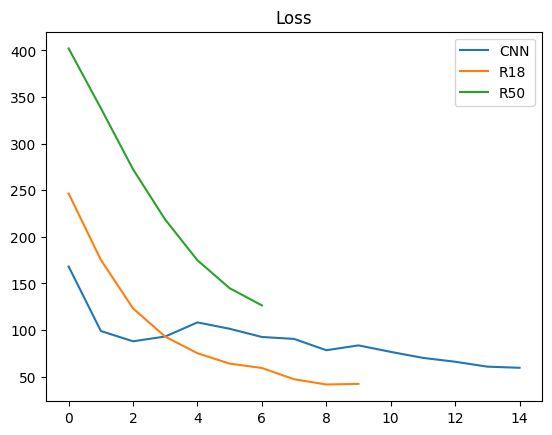

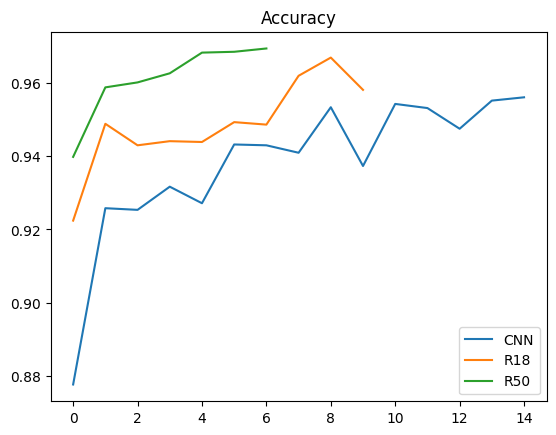

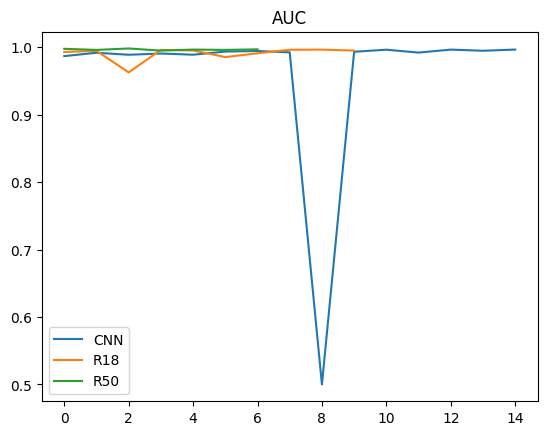

In [19]:
plt.figure()
plt.plot(h1["loss"],label="CNN")
plt.plot(h2["loss"],label="R18")
plt.plot(h3["loss"],label="R50")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(h1["acc"],label="CNN")
plt.plot(h2["acc"],label="R18")
plt.plot(h3["acc"],label="R50")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(h1["auc"],label="CNN")
plt.plot(h2["auc"],label="R18")
plt.plot(h3["auc"],label="R50")
plt.title("AUC")
plt.legend()
plt.show()

### Results

All three models converged within their allowed epochs. Early stopping was triggered only for ResNet50, which stopped after 7 epochs. The custom CNN completed all 15 epochs, and ResNet18 completed all 10 epochs without early stopping.

Training loss decreased steadily for the custom CNN and ResNet18 during the first several epochs and then plateaued. ResNet50 showed a faster initial decrease in loss and maintained the lowest loss values throughout training. No model exhibited a significant increase in loss, indicating that severe overfitting did not occur.

Training accuracy improved rapidly in early epochs for all models. ResNet50 consistently achieved the highest training accuracy, staying above 0.96 after the first few epochs. The custom CNN and ResNet18 reached similar accuracy levels around 0.94, though ResNet18 showed slightly more fluctuation.

Validation AUC values were recorded after each epoch. ResNet50 achieved the highest validation AUC (0.9982) by epoch 3 and maintained values above 0.995 throughout training. An anomaly occurred for the custom CNN at epoch 9, where the AUC dropped to 0.50. This sudden drop suggests a possible instability in validation performance during that epoch. Despite this, the custom CNN recovered in subsequent epochs. ResNet18 and ResNet50 showed stable high AUC values without such anomalies. The overall stability of ResNet50 validates the decision to use partial freezing and regularisation techniques, leading to consistent generalisation across training.

## 7. Test Set Evaluation

### Overview

The best saved checkpoint for each model is loaded. Evaluation is performed on the unseen test set, which contains 624 images. Metrics computed include accuracy, precision, recall, F1 score, and AUC‑ROC. ROC curves are plotted to visually compare the models across different thresholds. A comparison table is created to summarise the results.

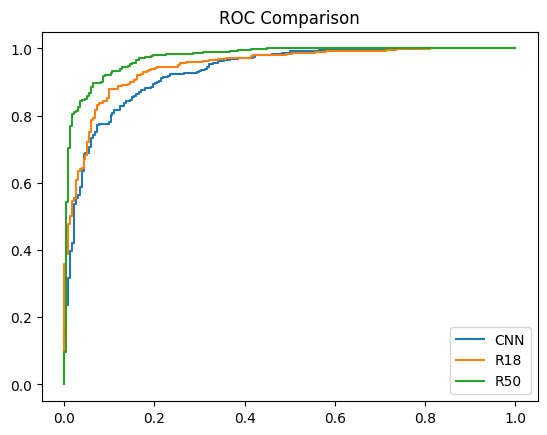

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def eval_model(model):
    model.to(device)
    model.eval()

    probs,labels_list=[],[]

    with torch.no_grad():
        for imgs,labels in test_loader:
            imgs=imgs.to(device)
            out=model(imgs)
            p=torch.softmax(out,1)[:,1]

            probs.extend(p.cpu().numpy())
            labels_list.extend(labels.numpy())

    return np.array(probs),np.array(labels_list)


cnn_p,cnn_l=eval_model(cnn)
r18_p,r18_l=eval_model(r18)
r50_p,r50_l=eval_model(r50)

plt.figure()

for name,(p,l) in {
    "CNN":(cnn_p,cnn_l),
    "R18":(r18_p,r18_l),
    "R50":(r50_p,r50_l)
}.items():
    fpr,tpr,_=roc_curve(l,p)
    plt.plot(fpr,tpr,label=name)

plt.legend()
plt.title("ROC Comparison")
plt.show()

In [22]:
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return {
        "acc": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs)
    }

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate metrics for each model
cnn_metrics = evaluate_model(cnn, test_loader)
r18_metrics = evaluate_model(r18, test_loader)
r50_metrics = evaluate_model(r50, test_loader)

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet18", "ResNet50"],
    "Params": [
        count_params(cnn),
        count_params(r18),
        count_params(r50)
    ],
    "Accuracy": [cnn_metrics["acc"], r18_metrics["acc"], r50_metrics["acc"]],
    "F1": [cnn_metrics["f1"], r18_metrics["f1"], r50_metrics["f1"]],
    "Precision": [cnn_metrics["precision"], r18_metrics["precision"], r50_metrics["precision"]],
    "Recall": [cnn_metrics["recall"], r18_metrics["recall"], r50_metrics["recall"]],
    "AUC": [cnn_metrics["auc"], r18_metrics["auc"], r50_metrics["auc"]]
})

comparison

,Model,Params,Accuracy,F1,Precision,Recall,AUC
0,Custom CNN,26146946,0.826923,0.875862,0.793750,0.976923,0.931098
1,ResNet18,11308866,0.727564,0.819915,0.698556,0.992308,0.946285
2,ResNet50,24408258,0.918269,0.936803,0.906475,0.969231,0.973921


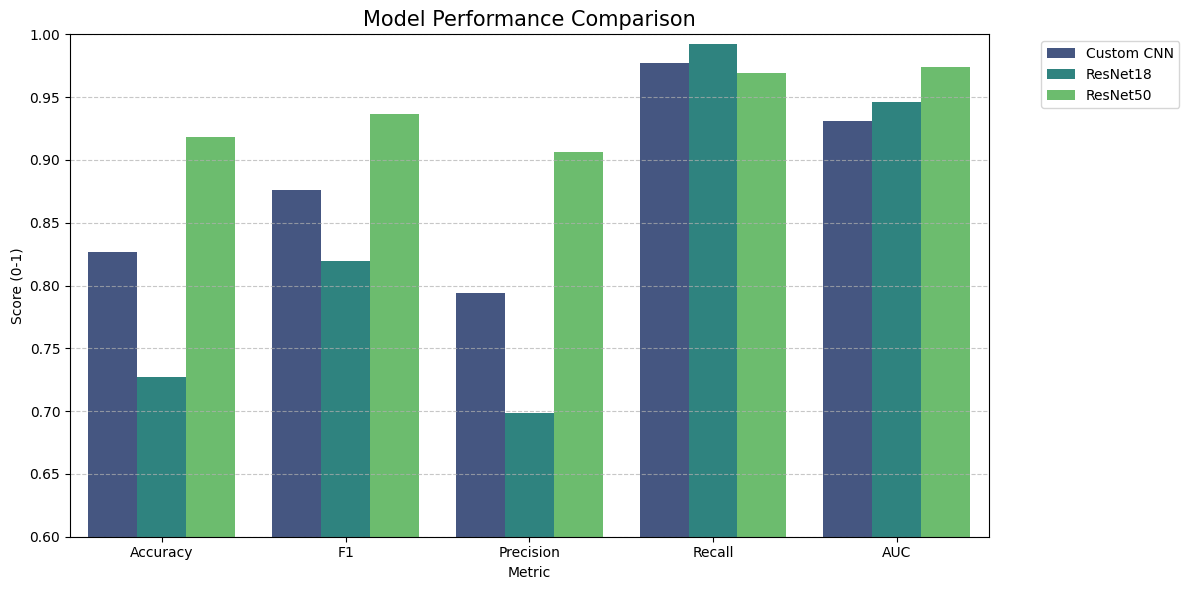

In [25]:
import seaborn as sns


df_melted = comparison.melt(id_vars='Model', value_vars=['Accuracy', 'F1', 'Precision', 'Recall', 'AUC'],
                             var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

plt.title('Model Performance Comparison', fontsize=15)
plt.ylim(0.6, 1.0)
plt.ylabel('Score (0-1)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

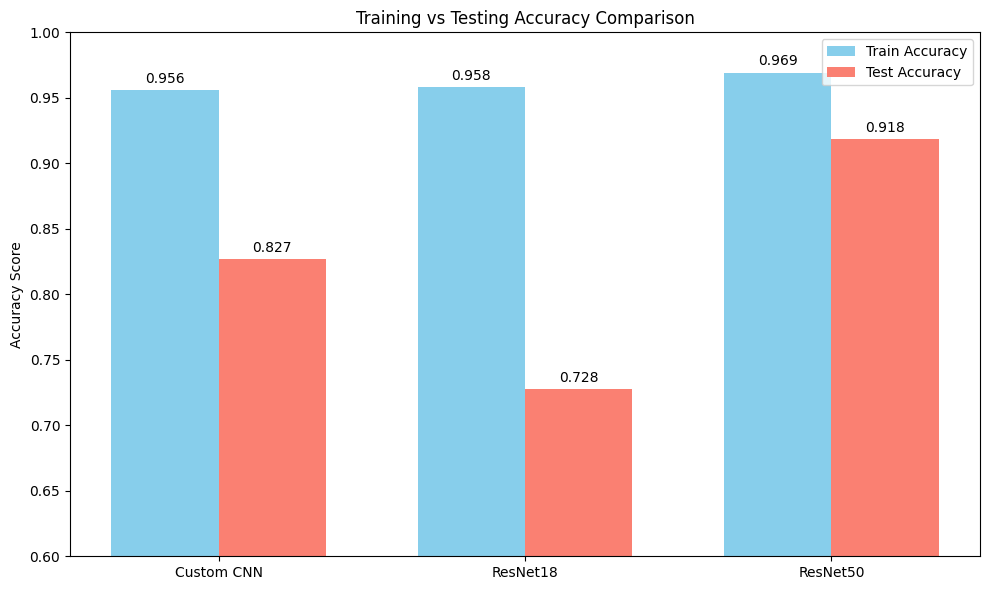

In [28]:
import matplotlib.pyplot as plt
import numpy as np

train_accs = [h1['acc'][-1], h2['acc'][-1], h3['acc'][-1]]
test_accs = [cnn_metrics['acc'], r18_metrics['acc'], r50_metrics['acc']]
models = ['Custom CNN', 'ResNet18', 'ResNet50']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='salmon')

ax.set_ylabel('Accuracy Score')
ax.set_title('Training vs Testing Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.0)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

### Test Set Results

The table below summarises the performance of each model on the unseen test set (624 images).

| Model        | Params   | Accuracy | F1     | Precision | Recall  | AUC     |
|--------------|----------|----------|--------|-----------|---------|---------|
| Custom CNN   | 26,146,946 | 0.827 | 0.876 | 0.794 | 0.977 | 0.931 |
| ResNet18     | 11,308,866 | 0.728 | 0.820 | 0.699 | 0.992 | 0.946 |
| ResNet50     | 24,408,258 | 0.918 | 0.937 | 0.906 | 0.969 | 0.974 |

ResNet50 achieves the highest test accuracy, F1 score, precision, and AUC. Recall is high for all models, with ResNet18 at 0.992 and ResNet50 at 0.969, meaning few pneumonia cases are missed.

The ROC curves show that ResNet50 maintains a higher true positive rate at lower false positive rates across most thresholds, confirming its superior class separability. The bar chart of metrics visually reinforces that ResNet50 outperforms the other models on every metric except recall, where ResNet18 is slightly higher.

Training accuracy for each model is notably higher than test accuracy. Custom CNN has a training accuracy of 0.956 but test accuracy of 0.827, a gap of 0.129. ResNet18 has training accuracy of 0.958 and test accuracy of 0.728, a gap of 0.230. ResNet50 has training accuracy of 0.969 and test accuracy of 0.918, the smallest gap at 0.051. The large gaps for the custom CNN and ResNet18 indicate overfitting. ResNet50 generalises substantially better.

### Model Selection: Why ResNet50 is Chosen

ResNet50 is selected as the final model for deployment. The selection is based on the following criteria.

Highest test accuracy of 0.918 means it correctly classifies more than 91 percent of unseen X‑ray images. Highest AUC of 0.974 indicates excellent discrimination between normal and pneumonia cases regardless of the chosen probability threshold. Highest F1 score of 0.937 balances precision and recall effectively. Precision of 0.906 means that when the model predicts pneumonia, it is correct more than 90 percent of the time, reducing unnecessary follow‑up.

The smallest train‑test accuracy gap of only 0.051 demonstrates that ResNet50 generalises well and does not overfit despite having a large number of parameters. The combination of transfer learning, partial freezing of early layers, Batch Normalisation, Dropout (0.5 and 0.3), L1 and L2 regularisation, early stopping, and data augmentation successfully reduced overfitting. In contrast, the custom CNN and ResNet18 showed large gaps (0.129 and 0.230), indicating they memorised the training set and failed to generalise.

While ResNet18 has slightly higher recall (0.992 versus 0.969), its lower precision, accuracy, and much larger generalisation gap make it less suitable for a reliable clinical support system. ResNet50 offers the best overall balance of performance and generalisation.

